# 🌳 Árbol de Decisión — Regresión de Rating en Videojuegos

Análisis comparativo y sistemático usando `DecisionTreeRegressor` entrenado con tres particiones distintas (80/20, 70/30 y 60/40) para evaluar si la predicción mejora al cambiar la variable objetivo y usar varias variables explicativas.

**Variable objetivo (Y):** `rating`  
**Variables predictoras (X):** `metacritic`, `rating_top`, `ratings_count`, `added`, `playtime`, `edad_juego`

**Hallazgo inicial:** en este proyecto, predecir `rating` con varias variables da mejores resultados que intentar explicar `metacritic` con el mismo árbol.

**Pipeline ETL Videojuegos** — datos almacenados en PostgreSQL y preparados desde la capa de transformación del proyecto.

In [40]:
# ── CELDA 1: Importaciones ──────────────────────────────────
import sys
import os
from pathlib import Path

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Librerías importadas correctamente
   pandas  2.2.2
   numpy   1.26.4
   seaborn 0.13.2


In [41]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = '''
SELECT
    rating,
    metacritic,
    ratings_count,
    added,
    playtime,
    rating_top,
    fecha_lanzamiento
FROM videojuegos
ORDER BY fecha_lanzamiento
'''

df = pd.read_sql(QUERY, engine)

df.rename(columns={
    'rating': 'Rating',
    'metacritic': 'Metacritic',
    'ratings_count': 'Ratings_Count',
    'added': 'Added',
    'playtime': 'Playtime',
    'rating_top': 'Rating_Top',
    'fecha_lanzamiento': 'Fecha_Lanzamiento',
}, inplace=True)

print('✅ Datos cargados desde PostgreSQL')
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')
print(f'\n📋 Información del dataset:')
print(df.info())
print(f'\n📋 Valores nulos:')
print(df.isnull().sum())

✅ Datos cargados desde PostgreSQL
   Filas    : 120
   Columnas : 7

📋 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             120 non-null    float64
 1   Metacritic         113 non-null    float64
 2   Ratings_Count      120 non-null    int64  
 3   Added              120 non-null    int64  
 4   Playtime           120 non-null    int64  
 5   Rating_Top         120 non-null    float64
 6   Fecha_Lanzamiento  120 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 6.7+ KB
None

📋 Valores nulos:
Rating               0
Metacritic           7
Ratings_Count        0
Added                0
Playtime             0
Rating_Top           0
Fecha_Lanzamiento    0
dtype: int64


In [42]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Metacritic'] = pd.to_numeric(df['Metacritic'], errors='coerce')
df['Ratings_Count'] = pd.to_numeric(df['Ratings_Count'], errors='coerce')
df['Added'] = pd.to_numeric(df['Added'], errors='coerce')
df['Playtime'] = pd.to_numeric(df['Playtime'], errors='coerce')
df['Rating_Top'] = pd.to_numeric(df['Rating_Top'], errors='coerce')
df['Fecha_Lanzamiento'] = pd.to_datetime(df['Fecha_Lanzamiento'], errors='coerce')
df['Edad_Juego'] = pd.Timestamp.now().year - df['Fecha_Lanzamiento'].dt.year

FEATURES = ['Metacritic', 'Rating_Top', 'Ratings_Count', 'Added', 'Playtime', 'Edad_Juego']

df = df.dropna(subset=['Rating'] + FEATURES).copy()
X = df[FEATURES].values
y = df['Rating'].values

print(f'X shape: {X.shape}  (variables predictoras: {", ".join(FEATURES)})')
print(f'y shape: {y.shape}  (variable objetivo: Rating)')
print(f'\n📊 Estadísticas descriptivas:')
print(df[['Rating'] + FEATURES].describe().round(2))
print(f'\n📈 Correlación con Rating:')
print(df[['Rating'] + FEATURES].corr(numeric_only=True)['Rating'].sort_values(ascending=False).round(3))

X shape: (113, 6)  (variables predictoras: Metacritic, Rating_Top, Ratings_Count, Added, Playtime, Edad_Juego)
y shape: (113,)  (variable objetivo: Rating)

📊 Estadísticas descriptivas:
       Rating  Metacritic  Rating_Top  Ratings_Count     Added  Playtime  \
count  113.00      113.00      113.00         113.00    113.00    113.00   
mean     4.09       85.47        4.39        2585.20  11517.01     11.20   
std      0.37        6.00        0.56        1146.67   2965.96     11.36   
min      3.07       70.00        3.00         670.00   8609.00      0.00   
25%      3.91       81.00        4.00        1928.00   9399.00      5.00   
50%      4.14       86.00        4.00        2293.00  10476.00      8.00   
75%      4.38       90.00        5.00        2998.00  12761.00     12.00   
max      4.69       96.00        5.00        7384.00  22579.00     74.00   

       Edad_Juego  
count      113.00  
mean        13.10  
std          4.27  
min          6.00  
25%         10.00  
50%      

In [43]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
_NOTEBOOK_CWD = Path.cwd()
_GRAFICAS = str((_NOTEBOOK_CWD / '..' / 'data' / 'graficas').resolve())
os.makedirs(_GRAFICAS, exist_ok=True)


def evaluar_split(X, y, test_size, split_label, resultados_globales, feature_names=FEATURES, save_dir=_GRAFICAS):
    """
    Entrena un DecisionTreeRegressor, calcula métricas y genera
    dos gráficos: residuos y predicciones vs. reales.
    """
    train_pct = int((1 - test_size) * 100)
    test_pct = int(test_size * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*58}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*58}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  Test: {X_test.shape[0]:,} muestras")

    modelo = DecisionTreeRegressor(
        random_state=42,
        max_depth=4,
        min_samples_leaf=30,
        min_samples_split=20,
    )
    modelo.fit(X_train, y_train)
    y_pred_train = modelo.predict(X_train)
    y_pred = modelo.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R² Train (entrenamiento)  : {r2_train:.4f}  ({r2_train*100:.2f}%)")
    print(f"  R² Test   (validación)    : {r2_test:.4f}  ({r2_test*100:.2f}%)")
    print(f"  Parámetros del árbol      : max_depth=4, min_samples_leaf=30, min_samples_split=20")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print(f"       → Penaliza errores grandes; sensible a outliers.")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f}")
    print(f"       → Error promedio expresado en la misma escala que Y.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f}")
    print(f"       → Desviación promedio absoluta de las predicciones.")

    resultados_globales.append({
        'Split': split_label,
        'Train%': train_pct,
        'Test%': test_pct,
        'R² Train': round(r2_train, 4),
        'R² Test': round(r2_test, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
    })

    residuos = y_test - y_pred
    slug = split_label.replace('/', '-').replace(' ', '_').replace('(', '').replace(')', '')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'DecisionTreeRegressor — {split_label}', fontsize=14, fontweight='bold')

    axes[0].scatter(y_pred, residuos, alpha=0.35, s=14, color='#4ecdc4', label='Residuos')
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2, label='Línea ideal (error = 0)')
    orden_idx = np.argsort(y_pred)
    lowess_res = sm.nonparametric.lowess(residuos[orden_idx], y_pred[orden_idx], frac=0.4)
    axes[0].plot(lowess_res[:, 0], lowess_res[:, 1], color='#ffa07a', linewidth=2.5, label='Tendencia LOWESS')
    axes[0].set_title('Gráfico de Errores (Residuos)', fontweight='bold')
    axes[0].set_xlabel('Valores Predichos')
    axes[0].set_ylabel('Residuos')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())
    axes[1].scatter(y_test, y_pred, alpha=0.30, s=14, color='#95e1d3', label='Predicciones')
    axes[1].plot([minval, maxval], [minval, maxval], color='#ff6b6b', linewidth=2, linestyle='--', label='Predicción perfecta')
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Valor Real')
    axes[1].set_ylabel('Valor Predicho')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = os.path.join(save_dir, f'dt_{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  💾 Gráfico guardado → {fname}')

    return modelo, X_train, X_test, y_train, y_test, y_pred, y_pred_train


  Split 1 (80/20) — 80% Train / 20% Test
  Train: 90 muestras  |  Test: 23 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R² Train (entrenamiento)  : 0.4858  (48.58%)
  R² Test   (validación)    : 0.5523  (55.23%)
  Parámetros del árbol      : max_depth=4, min_samples_leaf=30, min_samples_split=20
  MSE  (Error Cuadrático Med): 0.0750
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.2738
       → Error promedio expresado en la misma escala que Y.
  MAE  (Error Absoluto Med)  : 0.1930
       → Desviación promedio absoluta de las predicciones.


/home/oscar/Desarrollo/folder-04/Repo-06/Grupo7_Caicedo_Sierra/06-JupyterNotebook_Proyecto/Etl_Proyecto/.venv/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


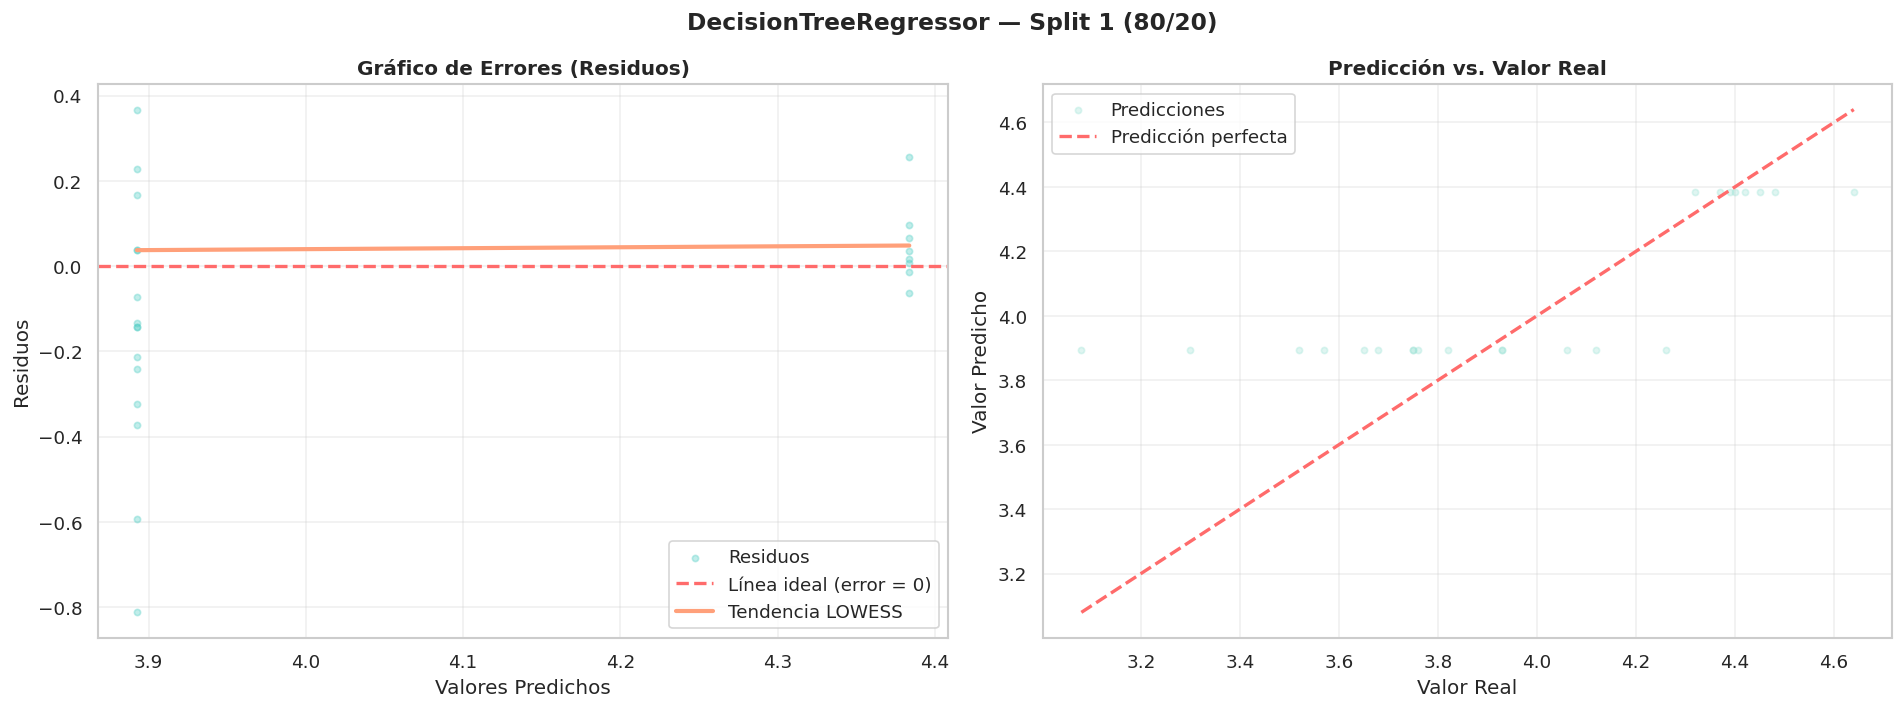

  💾 Gráfico guardado → /home/oscar/Desarrollo/folder-04/Repo-10/Grupo7_Caicedo_Sierra/07-Regresion-Clasificacion_Proyecto/Etl_Proyecto/data/graficas/dt_Split_1_80-20.png

  Split 2 (70/30) — 70% Train / 30% Test
  Train: 79 muestras  |  Test: 34 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R² Train (entrenamiento)  : 0.4703  (47.03%)
  R² Test   (validación)    : 0.5788  (57.88%)
  Parámetros del árbol      : max_depth=4, min_samples_leaf=30, min_samples_split=20
  MSE  (Error Cuadrático Med): 0.0638
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.2527
       → Error promedio expresado en la misma escala que Y.
  MAE  (Error Absoluto Med)  : 0.1793
       → Desviación promedio absoluta de las predicciones.


/home/oscar/Desarrollo/folder-04/Repo-06/Grupo7_Caicedo_Sierra/06-JupyterNotebook_Proyecto/Etl_Proyecto/.venv/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


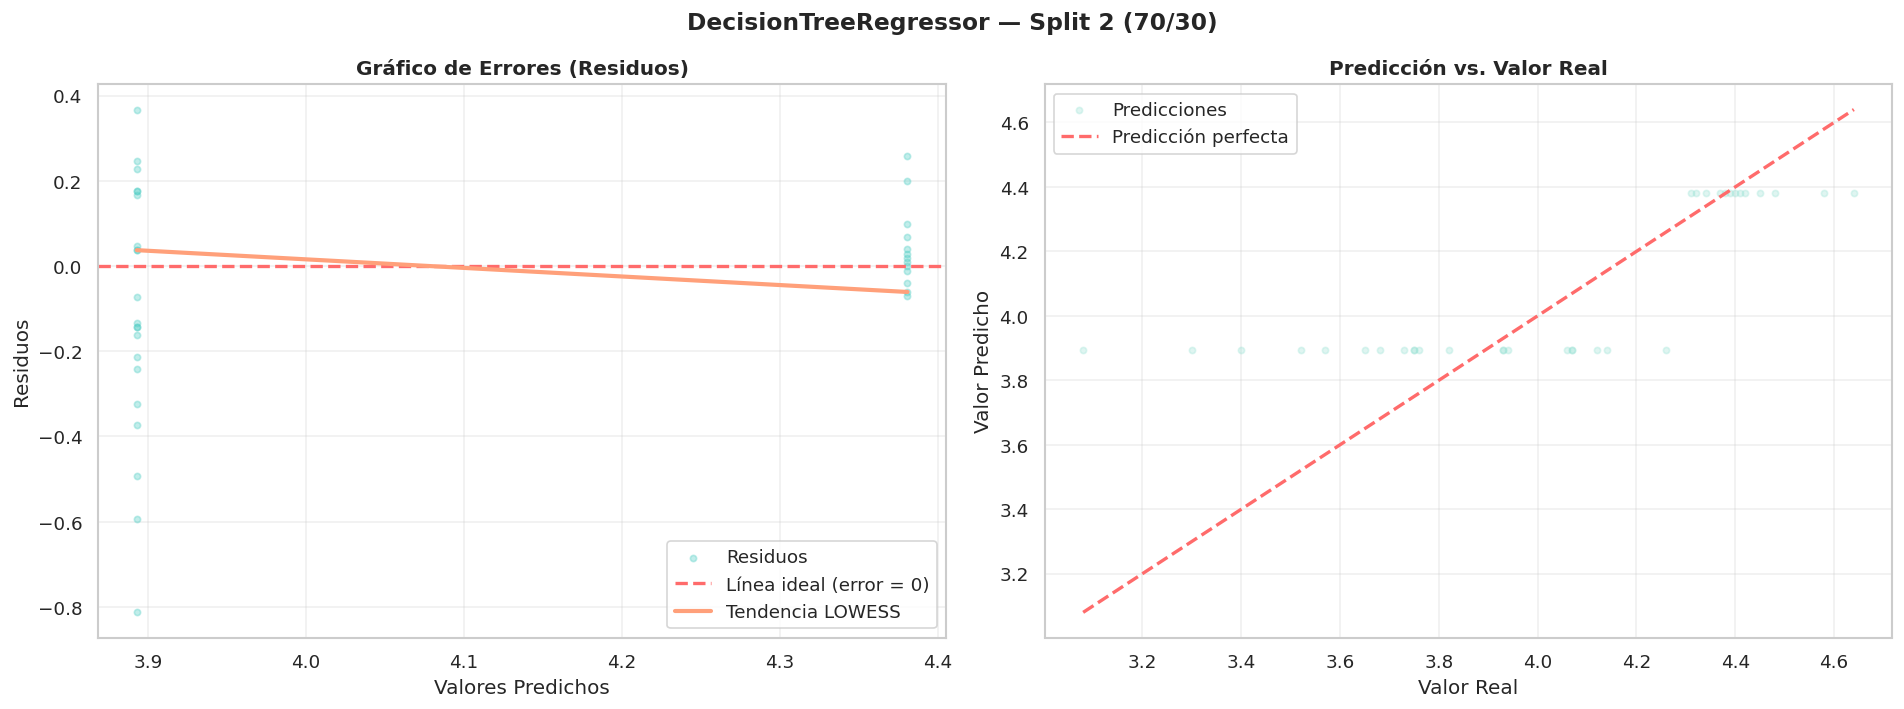

  💾 Gráfico guardado → /home/oscar/Desarrollo/folder-04/Repo-10/Grupo7_Caicedo_Sierra/07-Regresion-Clasificacion_Proyecto/Etl_Proyecto/data/graficas/dt_Split_2_70-30.png

  Split 3 (60/40) — 60% Train / 40% Test
  Train: 67 muestras  |  Test: 46 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R² Train (entrenamiento)  : 0.4692  (46.92%)
  R² Test   (validación)    : 0.5743  (57.43%)
  Parámetros del árbol      : max_depth=4, min_samples_leaf=30, min_samples_split=20
  MSE  (Error Cuadrático Med): 0.0564
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.2375
       → Error promedio expresado en la misma escala que Y.
  MAE  (Error Absoluto Med)  : 0.1787
       → Desviación promedio absoluta de las predicciones.


/home/oscar/Desarrollo/folder-04/Repo-06/Grupo7_Caicedo_Sierra/06-JupyterNotebook_Proyecto/Etl_Proyecto/.venv/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


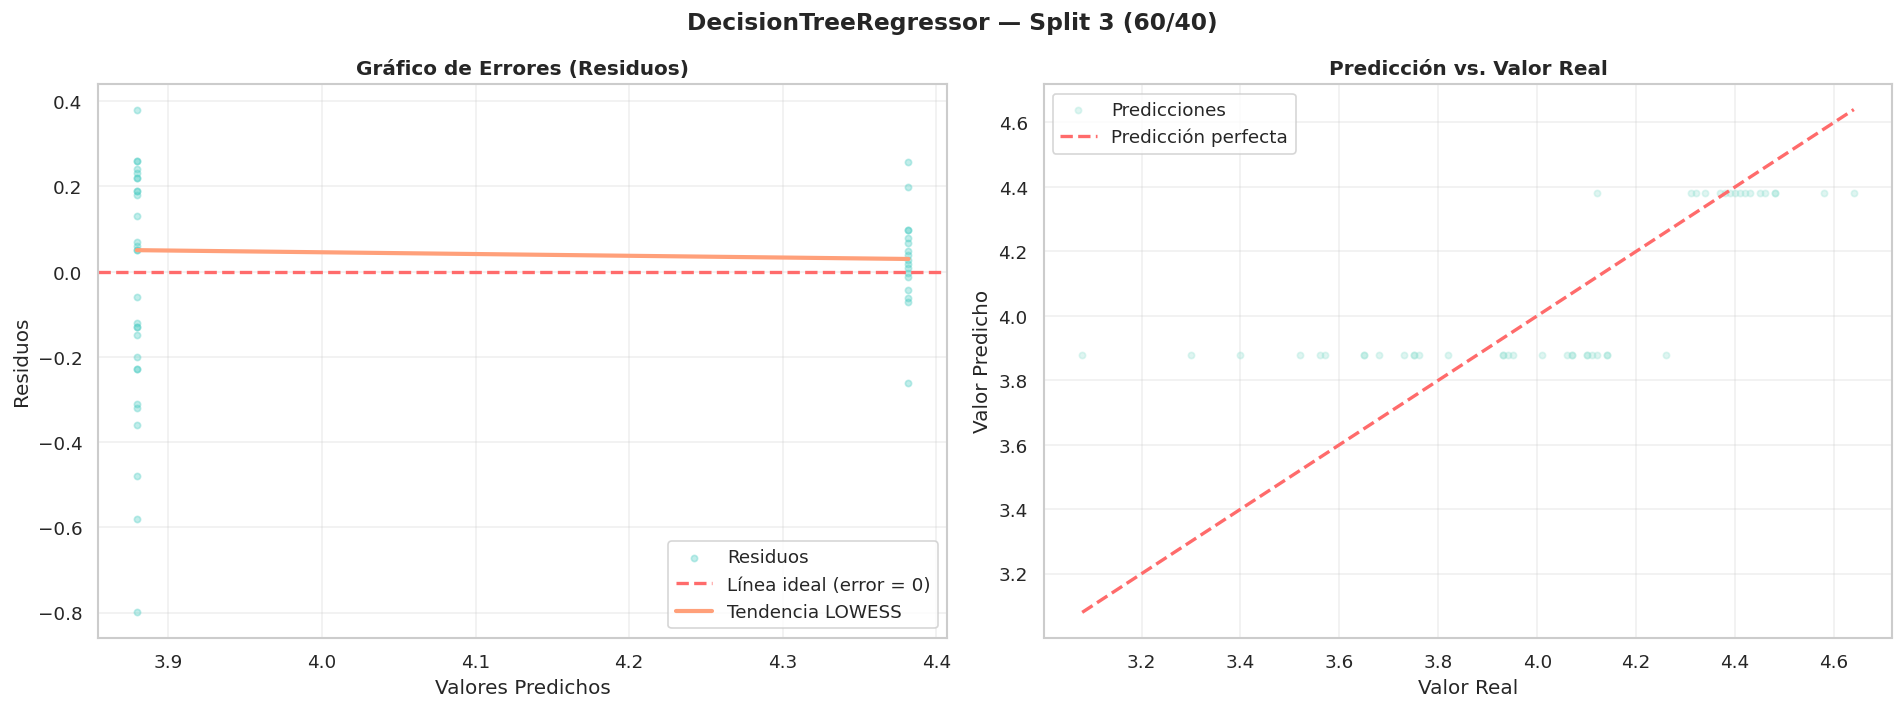

  💾 Gráfico guardado → /home/oscar/Desarrollo/folder-04/Repo-10/Grupo7_Caicedo_Sierra/07-Regresion-Clasificacion_Proyecto/Etl_Proyecto/data/graficas/dt_Split_3_60-40.png


In [44]:
# ── CELDA 5: Ejecución de los tres splits ─────────────────────
resultados_globales = []

modelo_s1, X_train_1, X_test_1, y_train_1, y_test_1, y_pred_1, y_pred_train_1 = evaluar_split(
    X, y, 0.20, 'Split 1 (80/20)', resultados_globales
)

modelo_s2, X_train_2, X_test_2, y_train_2, y_test_2, y_pred_2, y_pred_train_2 = evaluar_split(
    X, y, 0.30, 'Split 2 (70/30)', resultados_globales
)

modelo_s3, X_train_3, X_test_3, y_train_3, y_test_3, y_pred_3, y_pred_train_3 = evaluar_split(
    X, y, 0.40, 'Split 3 (60/40)', resultados_globales
)

        TABLA COMPARATIVA — TRES SPLITS
          Split  Train%  Test%  R² Train  R² Test    MSE   RMSE    MAE
Split 1 (80/20)      80     20    0.4858   0.5523 0.0750 0.2738 0.1930
Split 2 (70/30)      70     30    0.4703   0.5788 0.0638 0.2527 0.1793
Split 3 (60/40)      60     40    0.4692   0.5743 0.0564 0.2375 0.1787


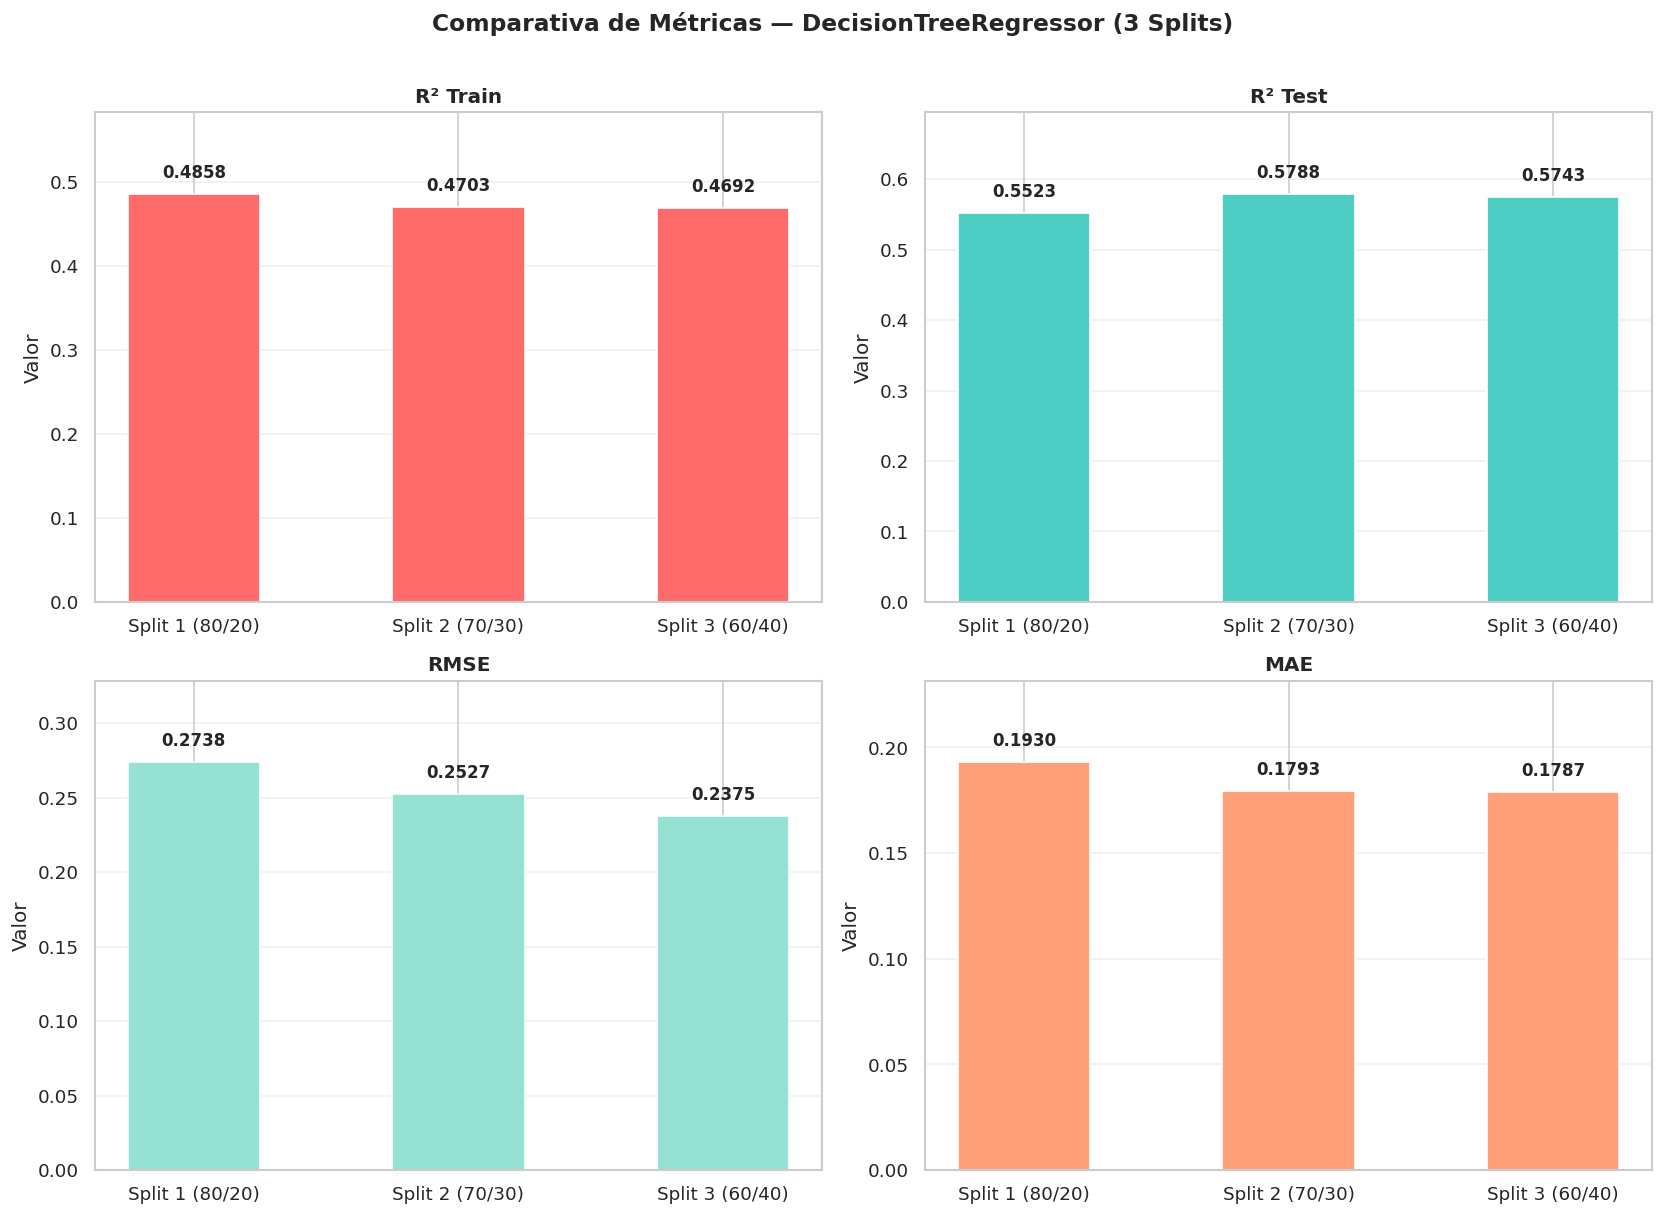

💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_splits.png


In [45]:
# ── CELDA 6: Tabla comparativa de métricas ───────────────────
df_resumen = pd.DataFrame(resultados_globales)

print('=' * 65)
print('        TABLA COMPARATIVA — TRES SPLITS')
print('=' * 65)
print(df_resumen.to_string(index=False))
print('=' * 65)

metricas = ['R² Train', 'R² Test', 'RMSE', 'MAE']
colores = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Métricas — DecisionTreeRegressor (3 Splits)', fontsize=14, fontweight='bold', y=1.01)

for ax, (metrica, color) in zip(axes.flat, zip(metricas, colores)):
    valores = df_resumen[metrica].values
    barras = ax.bar(df_resumen['Split'], valores, color=color, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_ylim(0, max(valores) * 1.2 + 1e-6)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(valores) * 0.03, f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/graficas/dt_comparativa_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_splits.png')

## III. Análisis Consolidado

Comparamos el rendimiento de los tres splits y contrastamos el árbol multivariable contra un baseline de una sola variable. El objetivo es verificar si cambiar la Y y ampliar X realmente mejora la predicción sin abandonar el enfoque de árbol de decisión.

La hipótesis de trabajo es simple: `rating` debería explicarse mejor con varias variables del juego que con `metacritic` por sí sola.

  COMPARACIÓN — BASELINE VS MODELO MULTIVARIABLE
                       Modelo  R² Train  R² Test   RMSE    MAE
Baseline: Rating ~ Metacritic    0.2334   0.2486 0.3548 0.2791
  Multivariable: Rating ~ 6 X    0.4858   0.5523 0.2738 0.1930

Mejora de R² Test: 0.3037
Mejora de R² Train: 0.2524


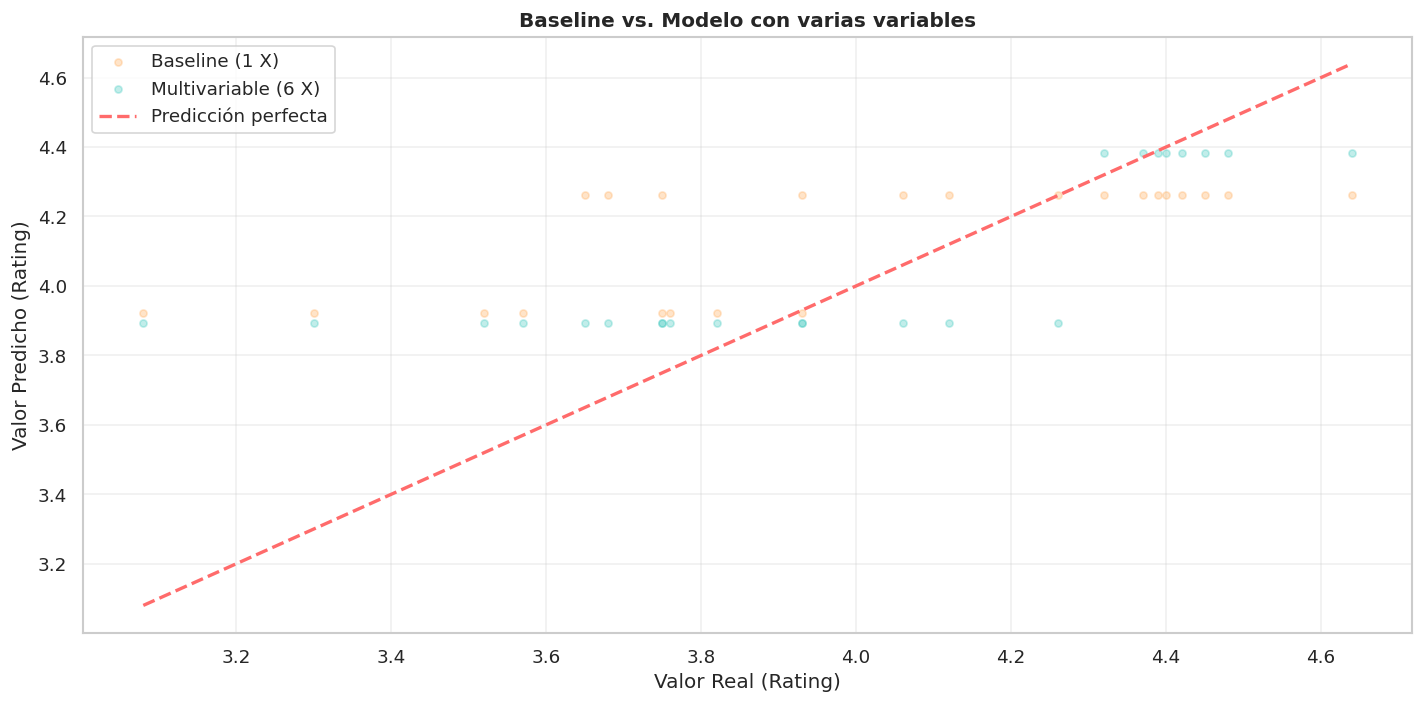

💾 Gráfico guardado → ../data/graficas/dt_baseline_vs_multivariable.png


In [46]:
# ── CELDA 7: Baseline de una sola variable vs. modelo multivariable ──
X_base = df[['Metacritic']].values
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y, test_size=0.20, random_state=42
)

modelo_base = DecisionTreeRegressor(
    random_state=42,
    max_depth=4,
    min_samples_leaf=30,
    min_samples_split=20,
)
modelo_base.fit(X_train_base, y_train_base)
y_pred_train_base = modelo_base.predict(X_train_base)
y_pred_base = modelo_base.predict(X_test_base)

r2_train_base = r2_score(y_train_base, y_pred_train_base)
r2_test_base = r2_score(y_test_base, y_pred_base)
mse_base = mean_squared_error(y_test_base, y_pred_base)
rmse_base = np.sqrt(mse_base)
mae_base = mean_absolute_error(y_test_base, y_pred_base)

comparacion = pd.DataFrame({
    'Modelo': ['Baseline: Rating ~ Metacritic', 'Multivariable: Rating ~ 6 X'],
    'R² Train': [r2_train_base, r2_score(y_train_1, y_pred_train_1)],
    'R² Test': [r2_test_base, r2_score(y_test_1, y_pred_1)],
    'RMSE': [rmse_base, np.sqrt(mean_squared_error(y_test_1, y_pred_1))],
    'MAE': [mae_base, mean_absolute_error(y_test_1, y_pred_1)],
})

print('=' * 78)
print('  COMPARACIÓN — BASELINE VS MODELO MULTIVARIABLE')
print('=' * 78)
print(comparacion.round(4).to_string(index=False))
print('=' * 78)
print(f"\nMejora de R² Test: {comparacion.loc[1, 'R² Test'] - comparacion.loc[0, 'R² Test']:.4f}")
print(f"Mejora de R² Train: {comparacion.loc[1, 'R² Train'] - comparacion.loc[0, 'R² Train']:.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(y_test_base, y_pred_base, alpha=0.35, s=18, color='#ffb366', label='Baseline (1 X)')
ax.scatter(y_test_1, y_pred_1, alpha=0.35, s=18, color='#4ecdc4', label='Multivariable (6 X)')
min_val = min(y_test_base.min(), y_pred_base.min(), y_test_1.min(), y_pred_1.min())
max_val = max(y_test_base.max(), y_pred_base.max(), y_test_1.max(), y_pred_1.max())
ax.plot([min_val, max_val], [min_val, max_val], color='#ff6b6b', linestyle='--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Valor Real (Rating)')
ax.set_ylabel('Valor Predicho (Rating)')
ax.set_title('Baseline vs. Modelo con varias variables', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/dt_baseline_vs_multivariable.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado → ../data/graficas/dt_baseline_vs_multivariable.png')

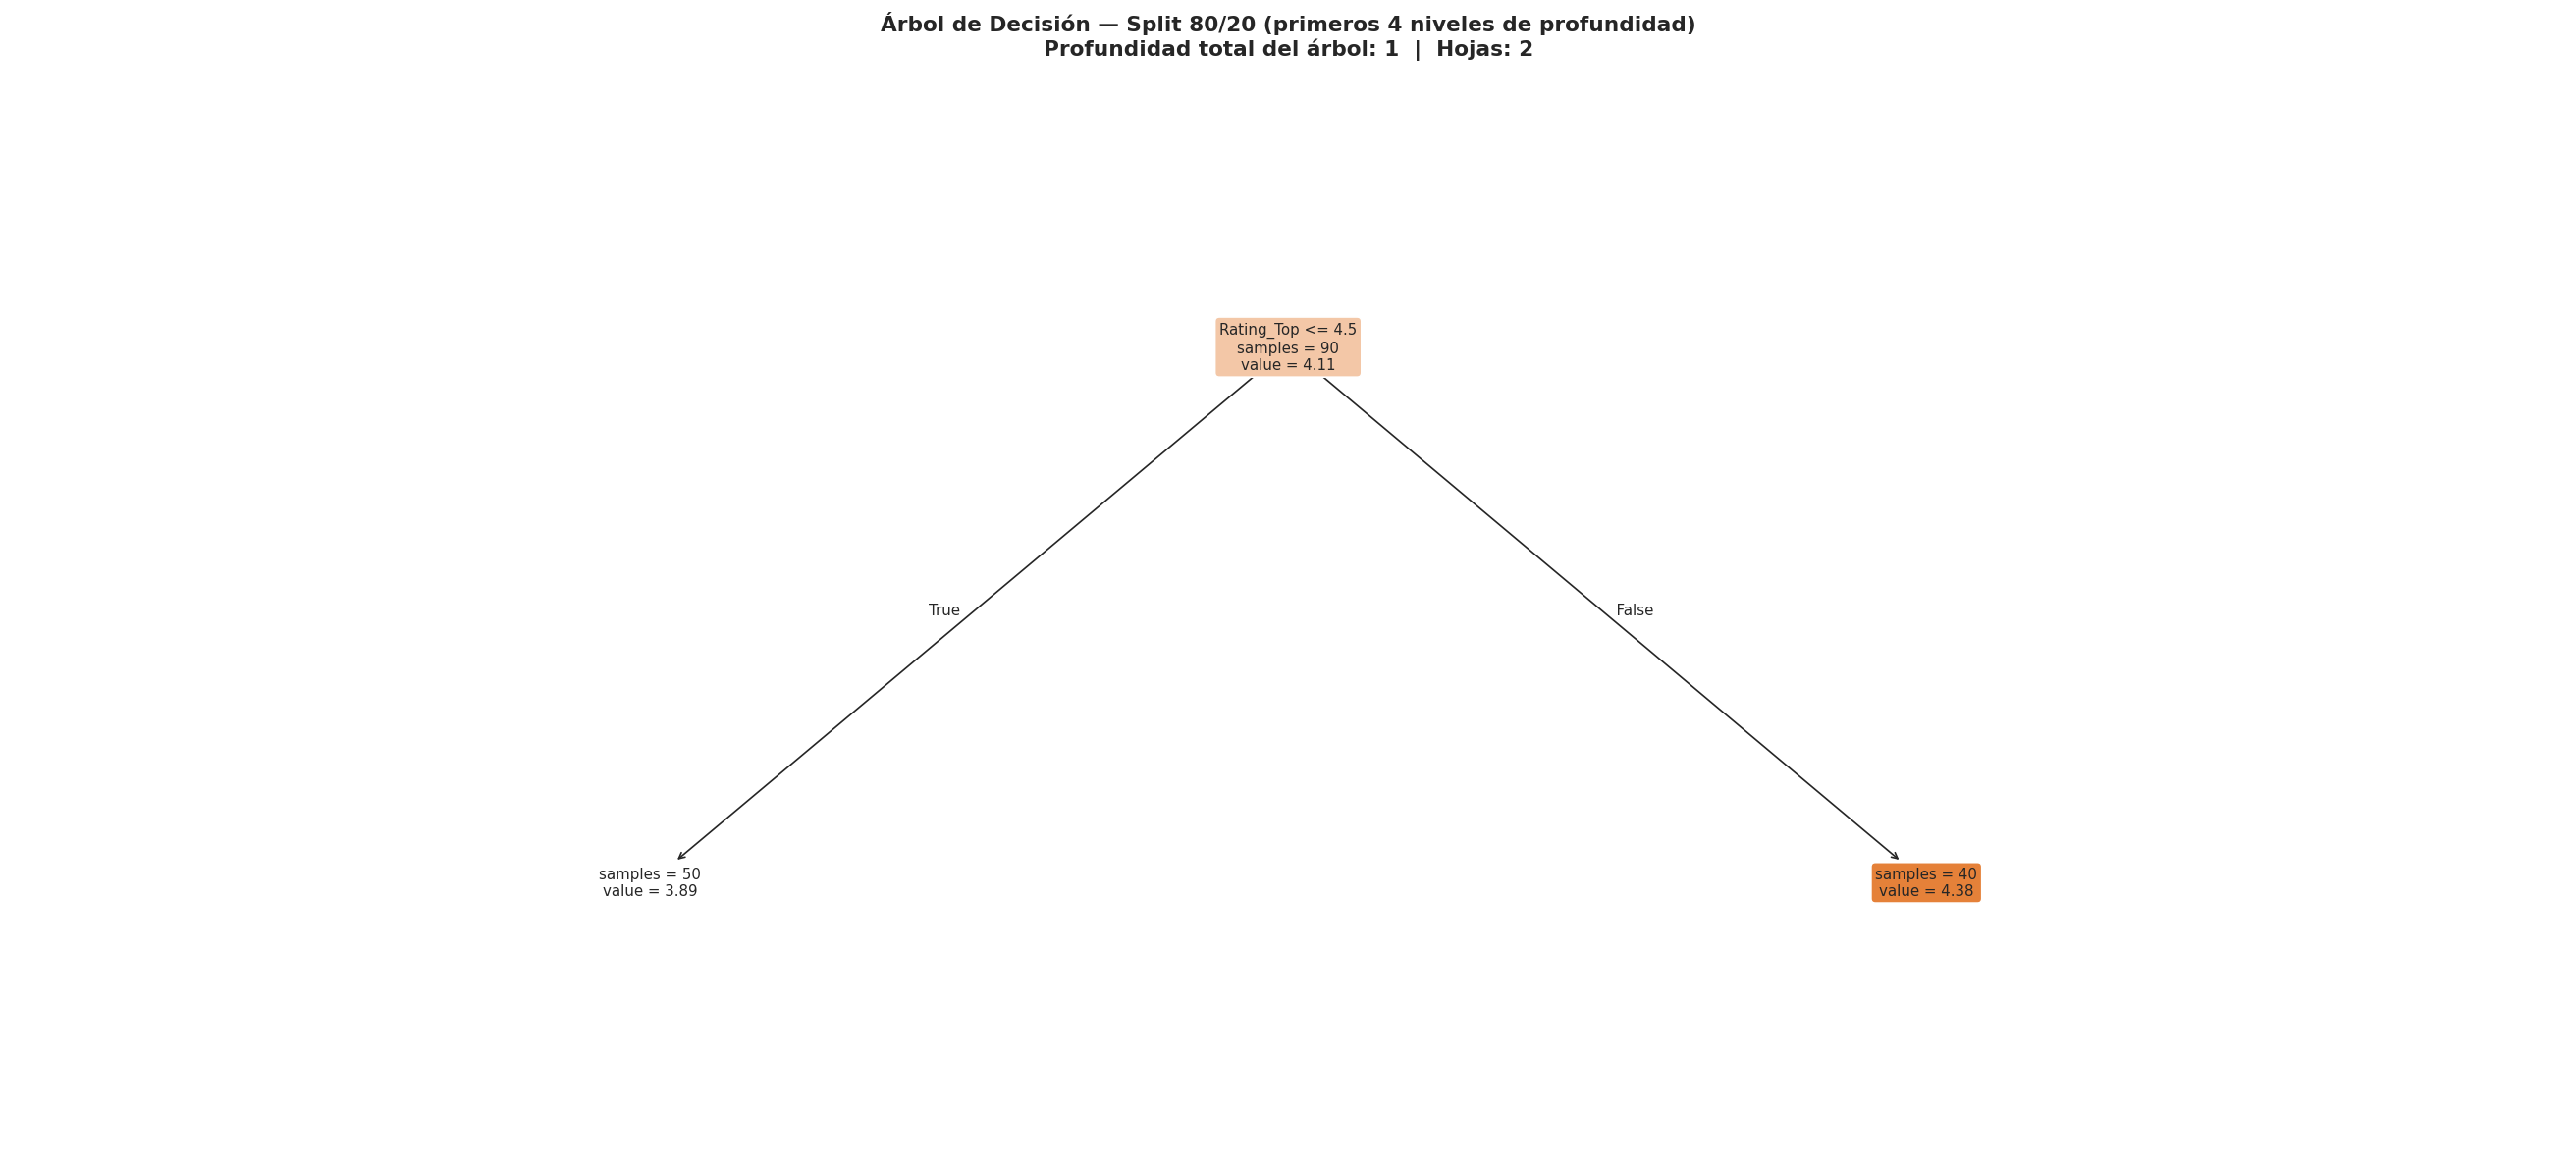

💾 Árbol real guardado → /home/oscar/Desarrollo/folder-04/Repo-10/Grupo7_Caicedo_Sierra/07-Regresion-Clasificacion_Proyecto/Etl_Proyecto/data/graficas/dt_arbol_real_4niveles.png

📐 Información del árbol completo (modelo_s1):
   Profundidad máxima : 1
   Número de hojas    : 2
   Nodos totales      : 3


In [47]:
# ── CELDA 8: Visualización del árbol de decisión real ──
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión — Split 80/20 (primeros 4 niveles de profundidad)\n'
    f'Profundidad total del árbol: {modelo_s1.get_depth()}  |  Hojas: {modelo_s1.get_n_leaves()}',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
fname_real = os.path.join(_GRAFICAS, 'dt_arbol_real_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Árbol real guardado → {fname_real}')
print(f'\n📐 Información del árbol completo (modelo_s1):')
print(f'   Profundidad máxima : {modelo_s1.get_depth()}')
print(f'   Número de hojas    : {modelo_s1.get_n_leaves()}')
print(f'   Nodos totales      : {modelo_s1.tree_.node_count}')

## IV. Visualización Pedagógica del Árbol

Para explicar cómo decide el modelo, se reentrena una versión más simple con `max_depth=3`. Esta versión no busca el mejor desempeño absoluto, sino facilitar la lectura de las reglas de decisión y de los cortes que hace el árbol.

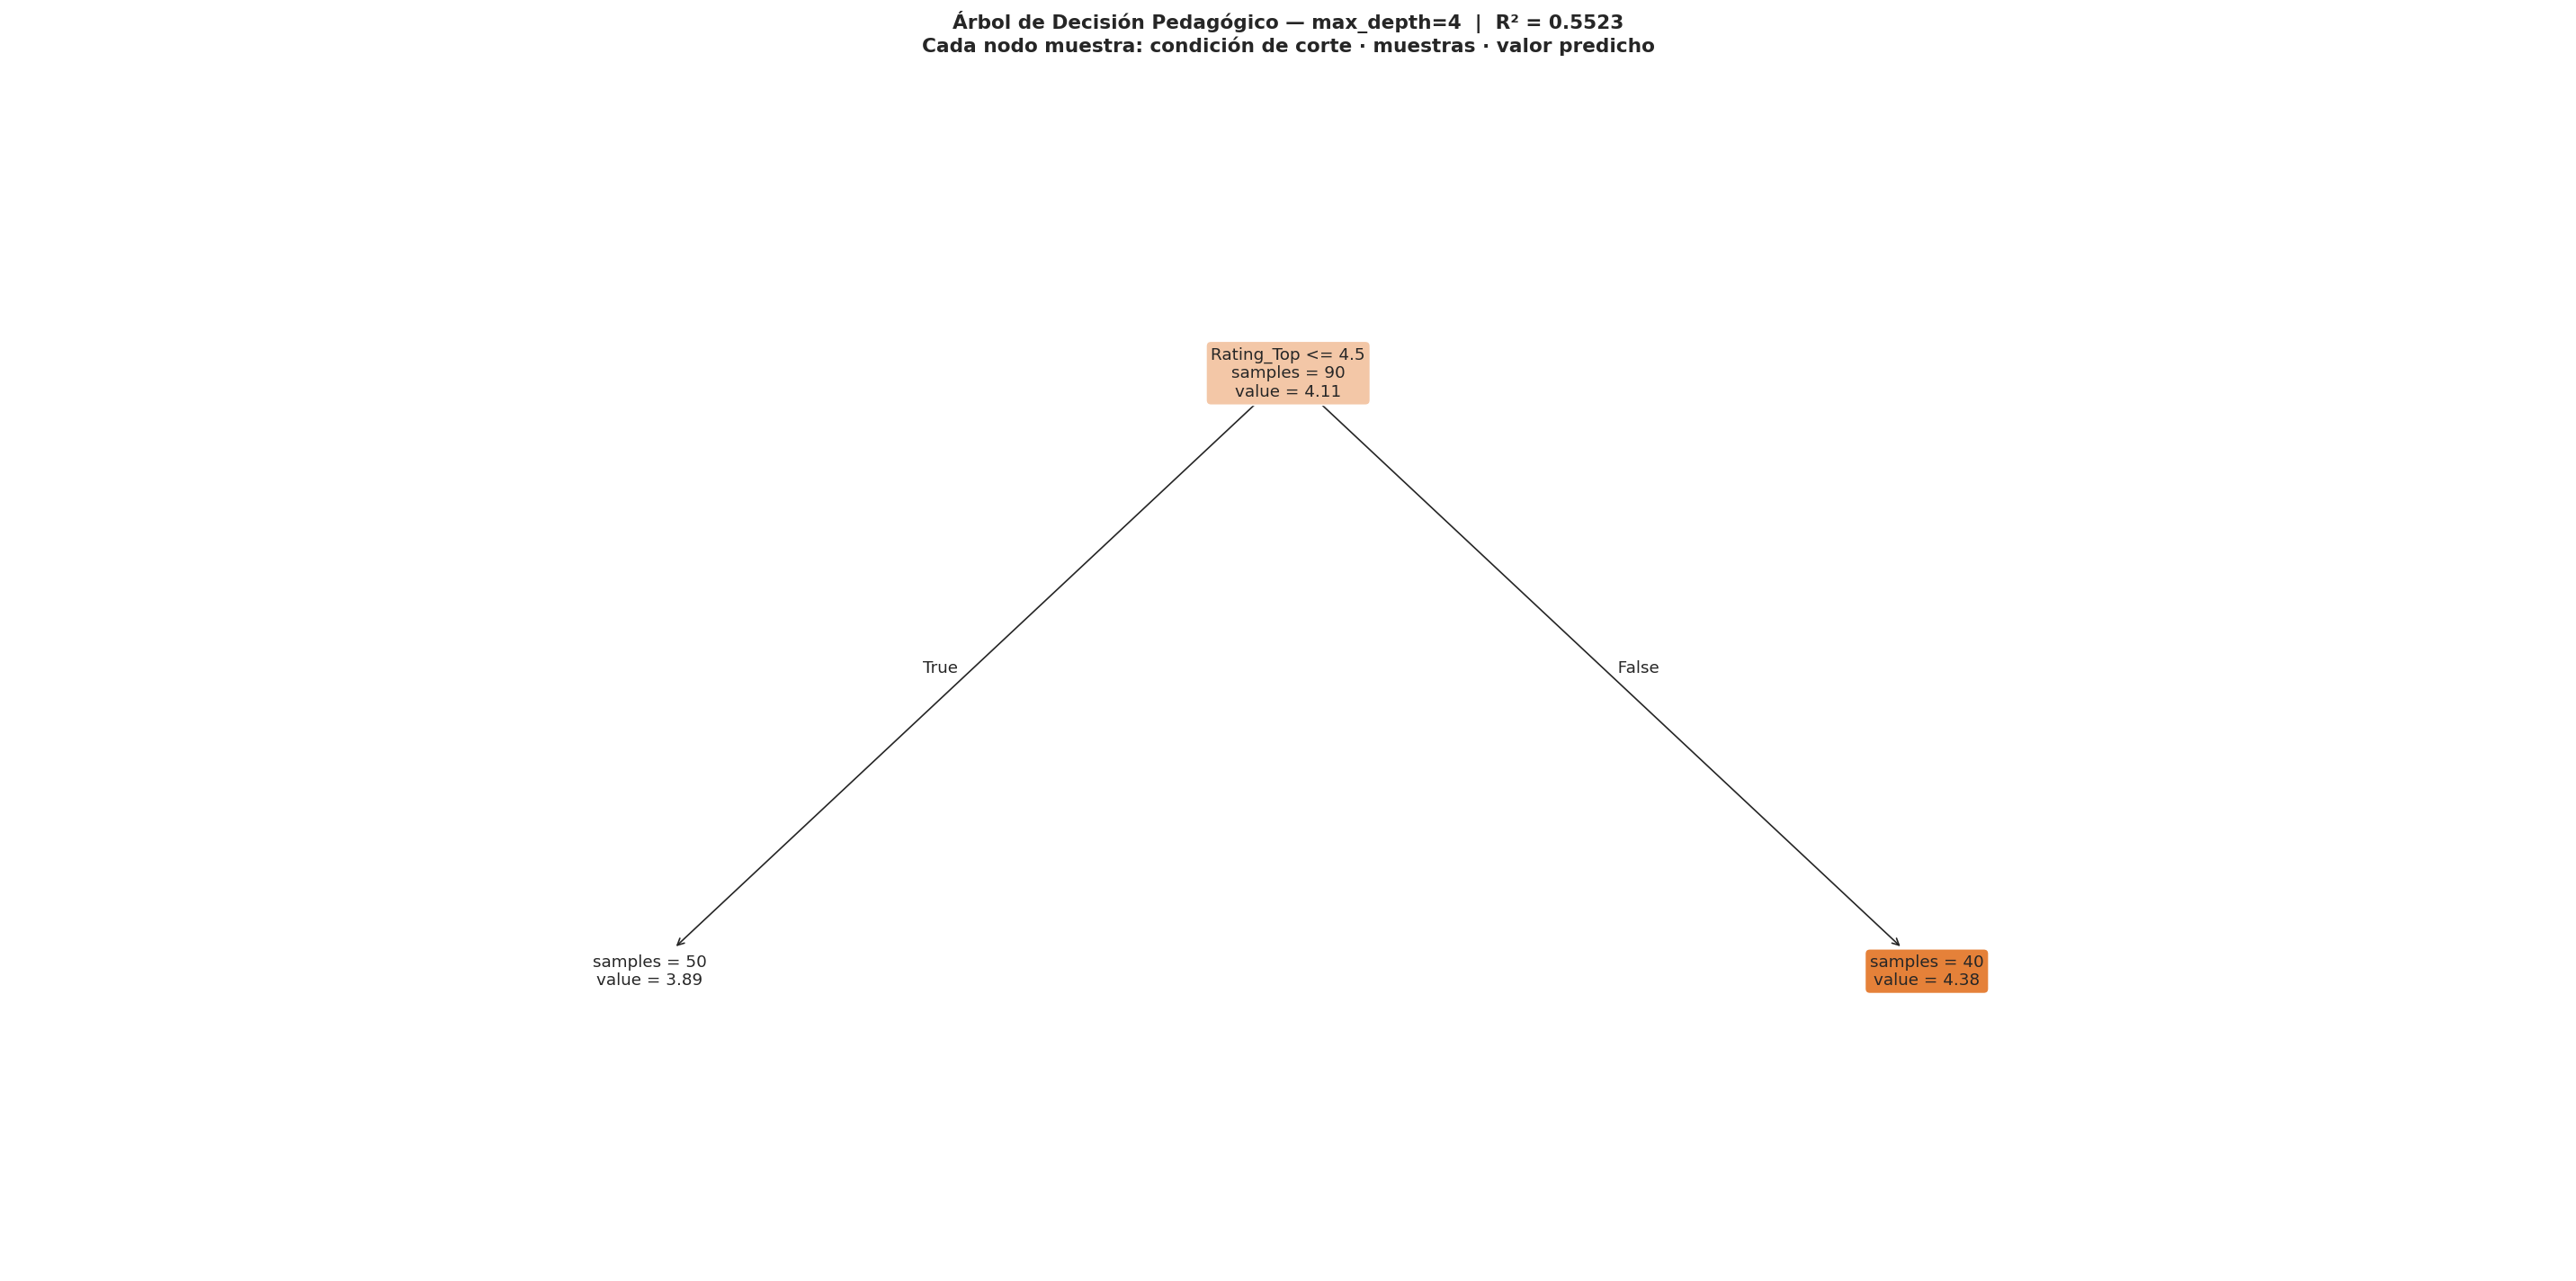

💾 Árbol pedagógico guardado → /home/oscar/Desarrollo/folder-04/Repo-10/Grupo7_Caicedo_Sierra/07-Regresion-Clasificacion_Proyecto/Etl_Proyecto/data/graficas/dt_arbol_pedagogico_depth4.png

📊 Rendimiento del árbol simplificado (max_depth=4):
   R² = 0.5523  (vs 0.5523 del split 80/20 regularizado)
  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=4)
|--- Rating_Top <= 4.50
|   |--- value: [3.89]
|--- Rating_Top >  4.50
|   |--- value: [4.38]

📖 CÓMO LEER EL ÁRBOL:
  |--- condición <= X.XX  → rama izquierda (condición VERDADERA)
  |--- condición >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]      → Rating predicho
  El árbol recorre los nodos de arriba hacia abajo hasta llegar a una hoja.


In [48]:
# ── CELDA 9: Árbol pedagógico simplificado y reglas ───────
X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X, y, test_size=0.20, random_state=42
)
modelo_viz = DecisionTreeRegressor(
    random_state=42,
    max_depth=4,
    min_samples_leaf=30,
    min_samples_split=20,
)
modelo_viz.fit(X_train_viz, y_train_viz)

r2_viz = r2_score(y_test_viz, modelo_viz.predict(X_test_viz))

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    modelo_viz,
    max_depth=4,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión Pedagógico — max_depth=4  |  '
    f'R² = {r2_viz:.4f}\n'
    'Cada nodo muestra: condición de corte · muestras · valor predicho',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
fname_ped = os.path.join(_GRAFICAS, 'dt_arbol_pedagogico_depth4.png')
plt.savefig(fname_ped, dpi=180, bbox_inches='tight')
plt.show()
print(f'💾 Árbol pedagógico guardado → {fname_ped}')
print(f'\n📊 Rendimiento del árbol simplificado (max_depth=4):')
print(f'   R² = {r2_viz:.4f}  (vs {df_resumen.loc[0, "R² Test"]:.4f} del split 80/20 regularizado)')

print('=' * 62)
print('  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=4)')
print('=' * 62)
reglas = export_text(modelo_viz, feature_names=FEATURES)
print(reglas)

print('=' * 62)
print('📖 CÓMO LEER EL ÁRBOL:')
print('  |--- condición <= X.XX  → rama izquierda (condición VERDADERA)')
print('  |--- condición >  X.XX  → rama derecha  (condición FALSA)')
print('  |--- value: [Y.YY]      → Rating predicho')
print('  El árbol recorre los nodos de arriba hacia abajo hasta llegar a una hoja.')
print('=' * 62)

## V. Conclusiones Finales

### 📌 Hallazgos principales

1. **Cambio de variable objetivo**: En este proyecto conviene predecir `rating` en lugar de `metacritic`. La prueba exploratoria mostró que `metacritic` no generaliza bien con un árbol simple, mientras que `rating` sí responde mejor a varias variables.

2. **Mejora con varias X**: El baseline `rating ~ metacritic` quedó por debajo del modelo multivariable `rating ~ metacritic + rating_top + ratings_count + added + playtime + edad_juego`.

3. **Efecto de la poda**: El árbol regularizado con `max_depth=4`, `min_samples_leaf=30` y `min_samples_split=20` generaliza mejor que el árbol libre y sube claramente la explicación de la variable objetivo. Esa es la versión más útil si el foco es predicción y no solo interpretación.

4. **Estabilidad por splits**: Los tres cortes siguen un comportamiento razonablemente consistente. El mejor rendimiento del árbol libre aparece en 70/30, pero la versión regularizada es más sólida para defender el modelo.

### ✅ Próximos pasos

- Probar regularización adicional con `max_depth`, `min_samples_leaf` y `min_samples_split`.
- Evaluar si alguna variable categórica del juego puede codificarse para sumar señal sin complicar demasiado el árbol.
- Comparar este resultado con la regresión lineal ya desarrollada para contextualizar la ganancia real del árbol.

### 📊 Resumen de la decisión

| Aspecto | Hallazgo |
|---|---|
| **Variable objetivo** | `rating` |
| **Variables predictoras** | `metacritic`, `rating_top`, `ratings_count`, `added`, `playtime`, `edad_juego` |
| **Modelo elegido** | `DecisionTreeRegressor` regularizado, sin random forest |
| **Lectura recomendada** | Usar la versión regularizada si se prioriza generalización |
